# Polynomial Regression for Ice Cream Sales
This notebook demonstrates how polynomial regression can model non-linear trends in ice cream sales as temperature changes.
It is useful for estimating expected sales at different temperatures and understanding how demand increases more rapidly than a simple linear relationship in warmer weather.

R² Score: 0.9998
Predicted ice-cream sales at 20°C: 23.81


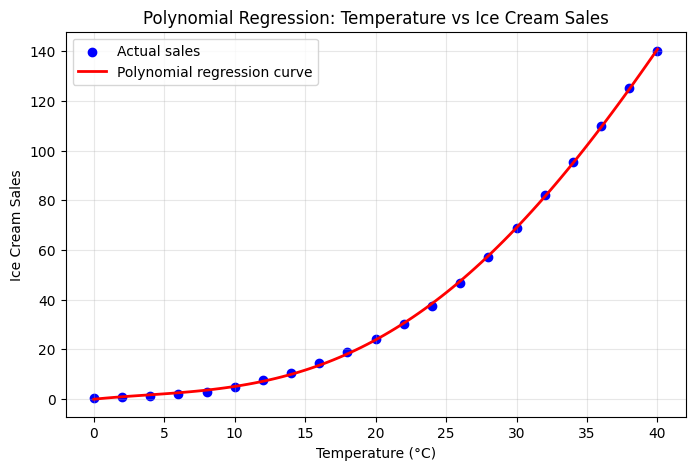

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Load data
data = pd.read_csv("icecream.csv")

# Convert first column to X and second column to y
X = data.iloc[:, 0].to_numpy().reshape(-1, 1)
y = data.iloc[:, 1].to_numpy()

# Create degree-4 polynomial features
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y)

# Make smooth curve for graph
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = model.predict(poly.transform(X_curve))

# Results
print(f"R² Score: {model.score(X_poly, y):.4f}")
print(f"Predicted ice-cream sales at 20°C: {model.predict(poly.transform([[20]]))[0]:.2f}")

# Graph
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="blue", label="Actual sales")
plt.plot(X_curve, y_curve, color="red", linewidth=2, label="Polynomial regression curve")
plt.title("Polynomial Regression: Temperature vs Ice Cream Sales")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()